# Parkinson’s Disease Detection from Voice (Classification)

## Objective

### The objective of this project is to analyze voice-based acoustic features and accurately detect Parkinson’s Disease using machine learning classification techniques.

## Dataset

The dataset consists of biomedical voice measurements extracted from speech recordings. It includes jitter, shimmer, harmonic-to-noise ratios, frequency-based features, and time–frequency domain features. A binary target variable represents whether a subject is healthy or affected by Parkinson’s Disease.

## Preprocessing

Removed non-informative identifiers

Checked and confirmed absence of missing values

Performed exploratory data analysis to understand class distribution and feature behavior

Standardized numerical features using StandardScaler

Applied Principal Component Analysis (PCA) to reduce dimensionality and noise

## Models Used

Support Vector Machine (SVM) with RBF kernel

Hyperparameter tuning using GridSearchCV

## Evaluation Metrics

Accuracy

Precision

Recall

F1-Score

Confusion Matrix

## Results

Baseline SVM achieved high classification accuracy

Feature scaling significantly improved model performance

PCA reduced feature dimensionality while preserving important variance

Hyperparameter tuning enhanced recall and overall classification balance

## Conclusion

Support Vector Machine proved to be an effective model for detecting Parkinson’s Disease from voice features. Proper preprocessing, feature scaling, and dimensionality reduction played a critical role in improving performance. The model demonstrates strong potential as a decision-support tool in early disease detection. Future work can explore ensemble and deep learning models for further accuracy improvements.

In [3]:
import pandas as pd 

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
df=pd.read_csv(r"C:\Users\chava\Downloads\pd_speech_features.csv\pd_speech_features.csv")
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [4]:
df.shape

(756, 755)

In [5]:
df.info

<bound method DataFrame.info of       id  gender      PPE      DFA     RPDE  numPulses  numPeriodsPulses  \
0      0       1  0.85247  0.71826  0.57227        240               239   
1      0       1  0.76686  0.69481  0.53966        234               233   
2      0       1  0.85083  0.67604  0.58982        232               231   
3      1       0  0.41121  0.79672  0.59257        178               177   
4      1       0  0.32790  0.79782  0.53028        236               235   
..   ...     ...      ...      ...      ...        ...               ...   
751  250       0  0.80903  0.56355  0.28385        417               416   
752  250       0  0.16084  0.56499  0.59194        415               413   
753  251       0  0.88389  0.72335  0.46815        381               380   
754  251       0  0.83782  0.74890  0.49823        340               339   
755  251       0  0.81304  0.76471  0.46374        340               339   

     meanPeriodPulses  stdDevPeriodPulses  locPctJitter

In [6]:
print("\nColumns:\n", df.columns)
print("\nTarget distribution:\n", df['class'].value_counts())


Columns:
 Index(['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses',
       'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter',
       ...
       'tqwt_kurtosisValue_dec_28', 'tqwt_kurtosisValue_dec_29',
       'tqwt_kurtosisValue_dec_30', 'tqwt_kurtosisValue_dec_31',
       'tqwt_kurtosisValue_dec_32', 'tqwt_kurtosisValue_dec_33',
       'tqwt_kurtosisValue_dec_34', 'tqwt_kurtosisValue_dec_35',
       'tqwt_kurtosisValue_dec_36', 'class'],
      dtype='object', length=755)

Target distribution:
 class
1    564
0    192
Name: count, dtype: int64


In [7]:
df.drop(columns=['id'], inplace=True)


In [8]:
df.isnull().sum().sum()


np.int64(0)

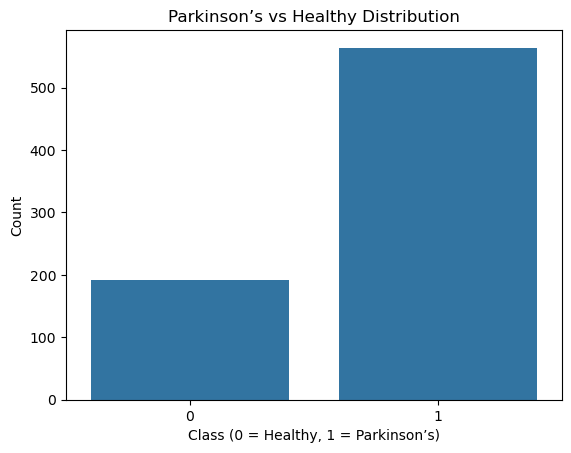

In [9]:
sns.countplot(x='class', data=df)
plt.title("Parkinson’s vs Healthy Distribution")
plt.xlabel("Class (0 = Healthy, 1 = Parkinson’s)")
plt.ylabel("Count")
plt.show()


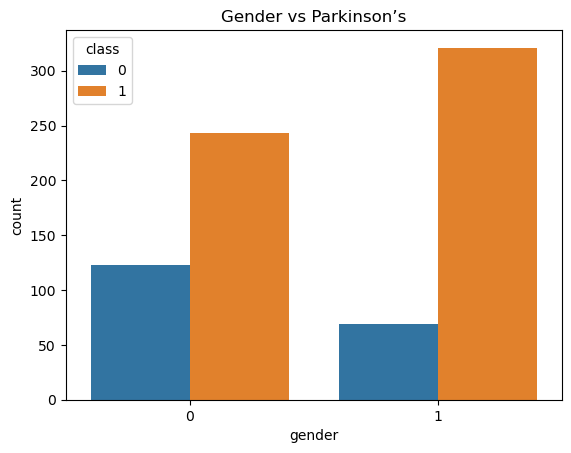

In [10]:
sns.countplot(x='gender', hue='class', data=df)
plt.title("Gender vs Parkinson’s")
plt.show()


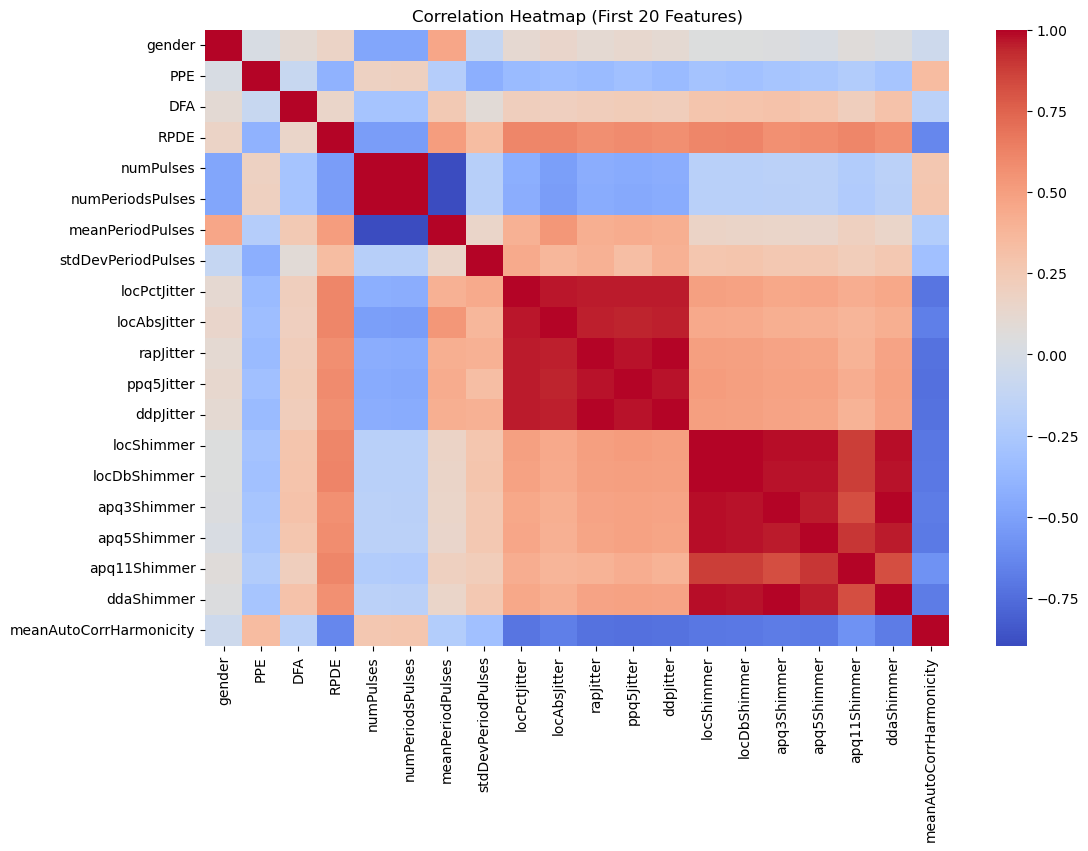

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.iloc[:, :20].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (First 20 Features)")
plt.show()


In [12]:
df.describe()


,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,7.560000e+02,...,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,0.515873,0.746284,0.700414,0.489058,323.972222,322.678571,0.006360,0.000383,0.002324,1.673391e-05,...,26.237251,22.840337,18.587888,13.872018,12.218953,12.375335,14.799230,14.751559,31.481110,0.746032
std,0.500079,0.169294,0.069718,0.137442,99.219059,99.402499,0.001826,0.000728,0.002628,2.290134e-05,...,42.220693,32.626464,25.537464,20.046029,17.783642,16.341665,15.722502,14.432979,34.230991,0.435568
min,0.000000,0.041551,0.543500,0.154300,2.000000,1.000000,0.002107,0.000011,0.000210,6.860000e-07,...,1.509800,1.531700,1.582900,1.747200,1.789500,1.628700,1.861700,1.955900,2.364000,0.000000
25%,0.000000,0.762833,0.647053,0.386537,251.000000,250.000000,0.005003,0.000049,0.000970,5.260000e-06,...,2.408675,3.452800,3.354825,3.077450,2.937025,3.114375,3.665925,3.741275,3.948750,0.000000
50%,1.000000,0.809655,0.700525,0.484355,317.000000,316.000000,0.006048,0.000077,0.001495,9.530000e-06,...,5.586300,7.062750,6.077400,4.770850,4.300450,4.741450,6.725700,7.334250,10.637250,1.000000
75%,1.000000,0.834315,0.754985,0.586515,384.250000,383.250000,0.007528,0.000171,0.002520,1.832500e-05,...,28.958075,29.830850,21.944050,13.188000,10.876150,12.201325,21.922050,22.495175,61.125325,1.000000
max,1.000000,0.907660,0.852640,0.871230,907.000000,905.000000,0.012966,0.003483,0.027750,2.564800e-04,...,239.788800,203.311300,121.542900,102.207000,85.571700,73.532200,62.007300,57.544300,156.423700,1.000000


In [13]:
X = df.drop(columns=['class'])
y = df['class']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("Reduced features after PCA:", X_train_pca.shape[1])


Original features: 753
Reduced features after PCA: 158


In [17]:
svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm.fit(X_train_pca, y_train)


,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
y_pred = svm.predict(X_test_pca)


In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8289473684210527


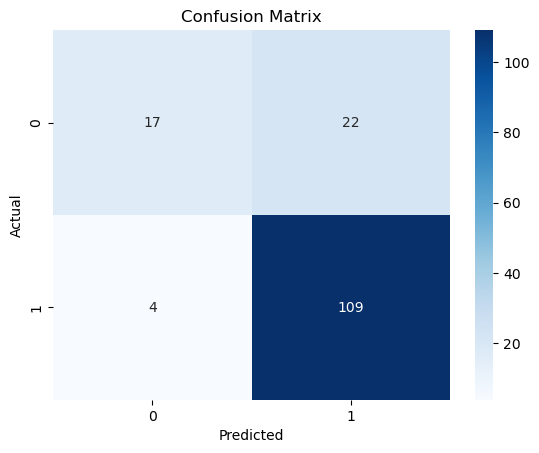

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [21]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.44      0.57        39
           1       0.83      0.96      0.89       113

    accuracy                           0.83       152
   macro avg       0.82      0.70      0.73       152
weighted avg       0.83      0.83      0.81       152



In [22]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [23]:
best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(X_test_pca)

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Final Accuracy: 0.8947368421052632
              precision    recall  f1-score   support

           0       0.85      0.72      0.78        39
           1       0.91      0.96      0.93       113

    accuracy                           0.89       152
   macro avg       0.88      0.84      0.85       152
weighted avg       0.89      0.89      0.89       152

